## Exploratory Data Analysis

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv('Data/application_train.csv')

# Create SQLite database
conn = sqlite3.connect('Data/loan_data.db')
df.to_sql('applications', conn, if_exists='replace', index=False)

# Basic overview
print(df.shape)


(307511, 122)


In [41]:
# Default rate by contract type
query = """
SELECT 
    NAME_CONTRACT_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY NAME_CONTRACT_TYPE
ORDER BY default_rate_pct DESC
"""
pd.read_sql_query(query, conn)

,NAME_CONTRACT_TYPE,total_applications,defaults,default_rate_pct
0,Cash loans,278232,23221,8.35
1,Revolving loans,29279,1604,5.48


In [25]:
# Check target variable balance
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True).round(3))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


In [26]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'percentage': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('percentage', ascending=False).head(20))

                          missing_count  percentage
COMMONAREA_MEDI                  214865   69.872297
COMMONAREA_AVG                   214865   69.872297
COMMONAREA_MODE                  214865   69.872297
NONLIVINGAPARTMENTS_MEDI         213514   69.432963
NONLIVINGAPARTMENTS_MODE         213514   69.432963
NONLIVINGAPARTMENTS_AVG          213514   69.432963
FONDKAPREMONT_MODE               210295   68.386172
LIVINGAPARTMENTS_MODE            210199   68.354953
LIVINGAPARTMENTS_MEDI            210199   68.354953
LIVINGAPARTMENTS_AVG             210199   68.354953
FLOORSMIN_MODE                   208642   67.848630
FLOORSMIN_MEDI                   208642   67.848630
FLOORSMIN_AVG                    208642   67.848630
YEARS_BUILD_MODE                 204488   66.497784
YEARS_BUILD_MEDI                 204488   66.497784
YEARS_BUILD_AVG                  204488   66.497784
OWN_CAR_AGE                      202929   65.990810
LANDAREA_AVG                     182590   59.376738
LANDAREA_MED

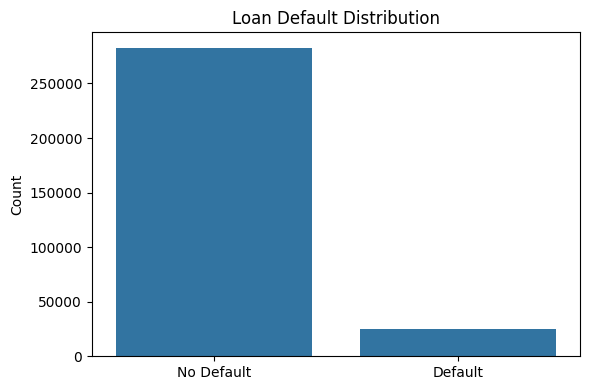

In [27]:
# Target distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title('Loan Default Distribution')
plt.xticks([0,1], ['No Default', 'Default'])
plt.xlabel('')
plt.ylabel('Count')
plt.tight_layout()
# plt.savefig('../outputs/target_distribution.png')
plt.show()

In [28]:
# Check columns with more than 40% missing - we'll likely drop these
high_missing = missing_df[missing_df['percentage'] > 40]
print(f"Columns with >40% missing: {len(high_missing)}")
print(high_missing)

Columns with >40% missing: 49
                              missing_count  percentage
OWN_CAR_AGE                          202929   65.990810
EXT_SOURCE_1                         173378   56.381073
APARTMENTS_AVG                       156061   50.749729
BASEMENTAREA_AVG                     179943   58.515956
YEARS_BEGINEXPLUATATION_AVG          150007   48.781019
YEARS_BUILD_AVG                      204488   66.497784
COMMONAREA_AVG                       214865   69.872297
ELEVATORS_AVG                        163891   53.295980
ENTRANCES_AVG                        154828   50.348768
FLOORSMAX_AVG                        153020   49.760822
FLOORSMIN_AVG                        208642   67.848630
LANDAREA_AVG                         182590   59.376738
LIVINGAPARTMENTS_AVG                 210199   68.354953
LIVINGAREA_AVG                       154350   50.193326
NONLIVINGAPARTMENTS_AVG              213514   69.432963
NONLIVINGAREA_AVG                    169682   55.179164
APARTMENTS_MODE   

In [29]:
# Drop high missing columns except EXT_SOURCE_1
cols_to_drop = high_missing.index.tolist()
cols_to_drop.remove('EXT_SOURCE_1')

df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping high missing columns: {df_clean.shape}")

# Check remaining missing values
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(f"\nRemaining columns with missing values: {len(remaining_missing)}")
print(remaining_missing.sort_values(ascending=False).head(20))

Shape after dropping high missing columns: (307511, 74)

Remaining columns with missing values: 19
EXT_SOURCE_1                  173378
OCCUPATION_TYPE                96391
EXT_SOURCE_3                   60965
AMT_REQ_CREDIT_BUREAU_YEAR     41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_HOUR     41519
NAME_TYPE_SUITE                 1292
DEF_60_CNT_SOCIAL_CIRCLE        1021
DEF_30_CNT_SOCIAL_CIRCLE        1021
OBS_60_CNT_SOCIAL_CIRCLE        1021
OBS_30_CNT_SOCIAL_CIRCLE        1021
EXT_SOURCE_2                     660
AMT_GOODS_PRICE                  278
AMT_ANNUITY                       12
CNT_FAM_MEMBERS                    2
DAYS_LAST_PHONE_CHANGE             1
dtype: int64


In [30]:
# Separate numerical and categorical columns
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

# Impute numerical columns with median
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical columns
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        if col == 'OCCUPATION_TYPE':
            df_clean[col] = df_clean[col].fillna('Unknown')
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verify no missing values remain
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")
print(f"Shape: {df_clean.shape}")

Remaining missing values: 0
Shape: (307511, 74)


/var/folders/9z/9l4k06054hz8brx99fkxrd5m0000gp/T/ipykernel_26544/2012522439.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns


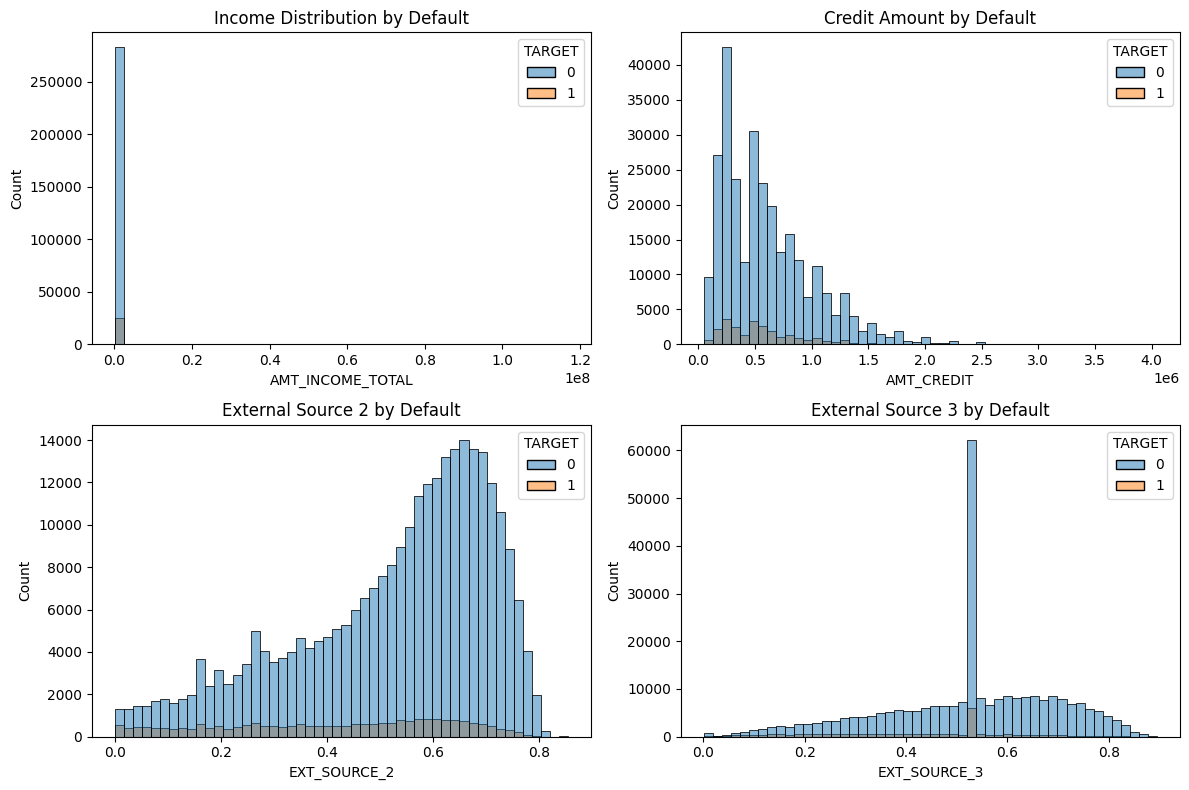

In [31]:
# Distribution of key numerical features by target
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df_clean, x='AMT_INCOME_TOTAL', hue='TARGET', bins=50, ax=axes[0,0])
axes[0,0].set_title('Income Distribution by Default')

sns.histplot(data=df_clean, x='AMT_CREDIT', hue='TARGET', bins=50, ax=axes[0,1])
axes[0,1].set_title('Credit Amount by Default')

sns.histplot(data=df_clean, x='EXT_SOURCE_2', hue='TARGET', bins=50, ax=axes[1,0])
axes[1,0].set_title('External Source 2 by Default')

sns.histplot(data=df_clean, x='EXT_SOURCE_3', hue='TARGET', bins=50, ax=axes[1,1])
axes[1,1].set_title('External Source 3 by Default')

plt.tight_layout()
plt.show()

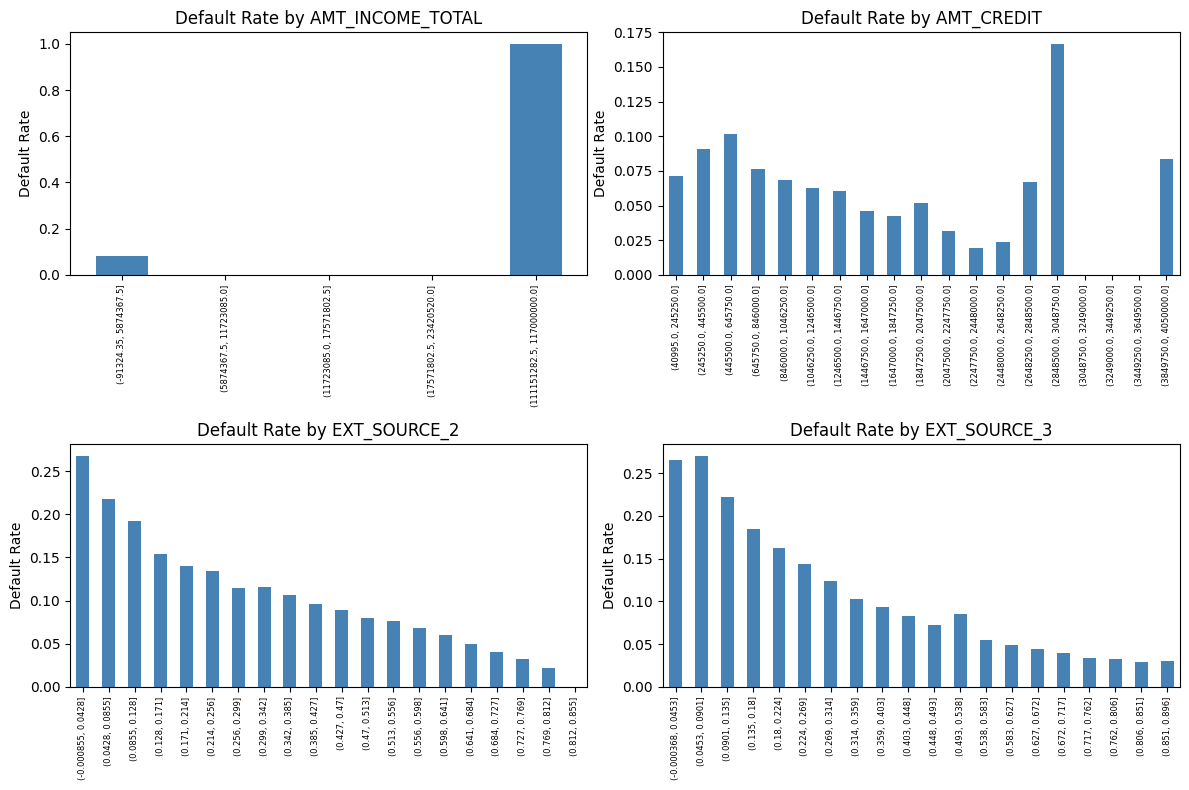

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    # Plot default rate across bins rather than raw counts
    df_clean['bin'] = pd.cut(df_clean[col], bins=20)
    default_rate = df_clean.groupby('bin', observed=True)['TARGET'].mean()
    default_rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()


plt.show()

# Clean up temp column
df_clean = df_clean.drop(columns=['bin'])

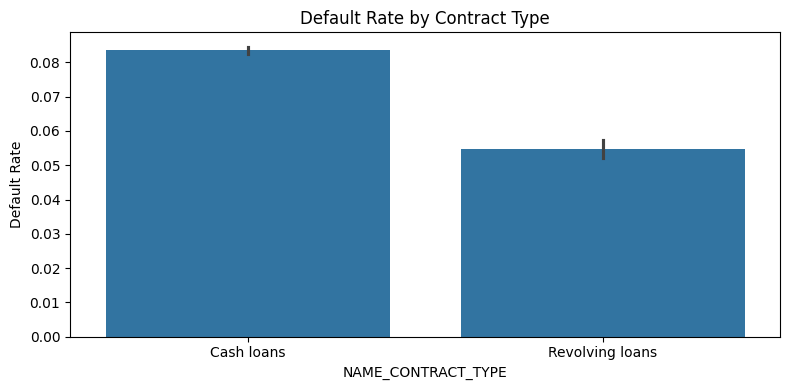

In [33]:
# Default rate by contract type
plt.figure(figsize=(8,4))
sns.barplot(data=df_clean, x='NAME_CONTRACT_TYPE', y='TARGET')
plt.title('Default Rate by Contract Type')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

In [34]:
# Correlation of numerical features with target
correlations = df_clean[num_cols].corr()['TARGET'].sort_values()
print("Most negatively correlated with default:")
print(correlations.head(10))
print("\nMost positively correlated with default:")
print(correlations.tail(10))

Most negatively correlated with default:
EXT_SOURCE_2                 -0.160295
EXT_SOURCE_3                 -0.155892
EXT_SOURCE_1                 -0.098887
DAYS_EMPLOYED                -0.044932
AMT_GOODS_PRICE              -0.039623
REGION_POPULATION_RELATIVE   -0.037227
AMT_CREDIT                   -0.030369
FLAG_DOCUMENT_6              -0.028602
HOUR_APPR_PROCESS_START      -0.024166
FLAG_PHONE                   -0.023806
Name: TARGET, dtype: float64

Most positively correlated with default:
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64
